## Importing libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

---

## TASK 1

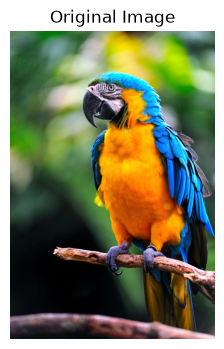

In [3]:
img = cv2.imread('images/input.jpg')

# Convert BGR to RGB for displaying with matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 4))
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off');

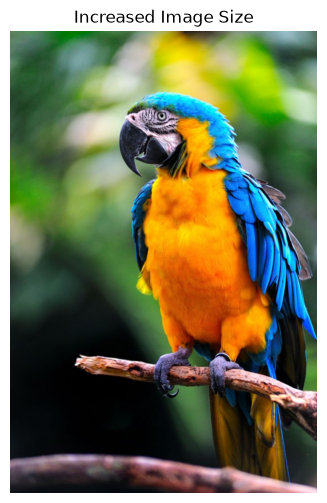

In [4]:
height, width = img.shape[:2]

scaled_img = cv2.resize(
    img,
    (width * 2, height * 2),
    interpolation=cv2.INTER_LINEAR
)

scaled_rgb = cv2.cvtColor(scaled_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(scaled_rgb)
plt.title('Increased Image Size')
plt.axis('off');

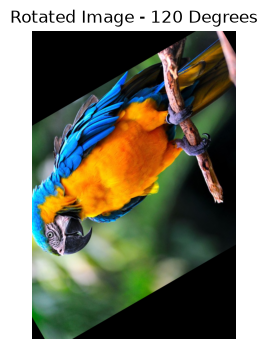

In [5]:
height, width = img.shape[:2]

center = (width // 2, height // 2)

rotation_matrix = cv2.getRotationMatrix2D(center, 120, 1.0)

rotated_img = cv2.warpAffine(
    img,
    rotation_matrix,
    (width, height)
)

rotated_rgb = cv2.cvtColor(rotated_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 4))
plt.imshow(rotated_rgb)
plt.title('Rotated Image - 120 Degrees')
plt.axis('off');

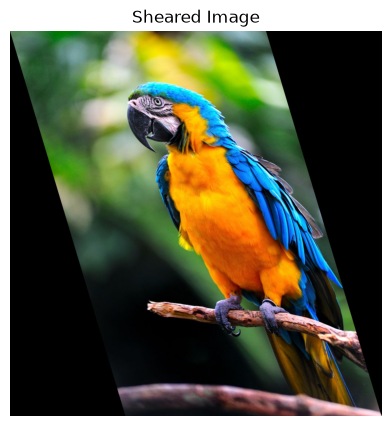

In [6]:
height, width = img.shape[:2]

shear_factor = 0.3

shear_matrix = np.float32([
    [1, shear_factor, 0],
    [0, 1, 0]
])

sheared_img = cv2.warpAffine(
    img,
    shear_matrix,
    (int(width + shear_factor * height), height)
)

sheared_rgb = cv2.cvtColor(sheared_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7, 5))
plt.imshow(sheared_rgb)
plt.title('Sheared Image')
plt.axis('off');

---

## TASK 2

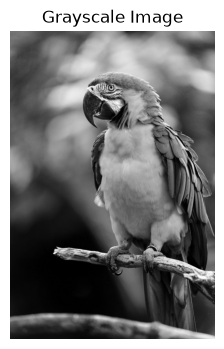

In [7]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 4))
plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off');

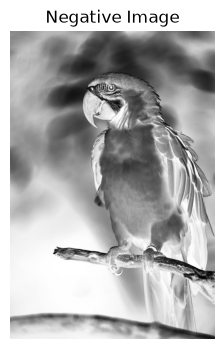

In [8]:
negative = 255 - gray

plt.figure(figsize=(6, 4))
plt.imshow(negative, cmap='gray')
plt.title('Negative Image')
plt.axis('off');

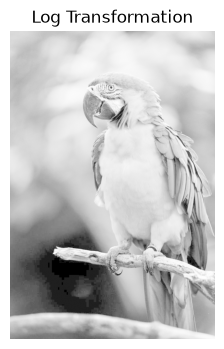

In [9]:
gray_float = gray.astype(np.float32)

c = 255 / np.log(1 + np.max(gray_float))

log_img = c * np.log(1 + gray_float)

log_img = np.uint8(np.clip(log_img, 0, 255))

plt.figure(figsize=(6, 4))
plt.imshow(log_img, cmap='gray')
plt.title('Log Transformation')
plt.axis('off');

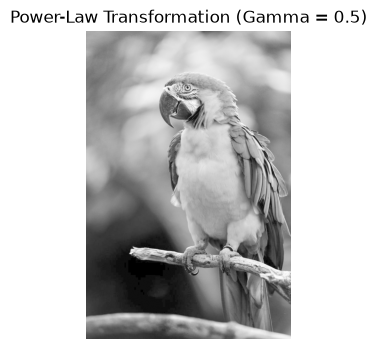

In [10]:
gamma = 0.5

normalized = gray / 255.0

power_img = np.power(normalized, gamma)

power_img = np.uint8(power_img * 255)

plt.figure(figsize=(6, 4))
plt.imshow(power_img, cmap='gray')
plt.title('Power-Law Transformation (Gamma = 0.5)')
plt.axis('off');

---

## Saving results

In [12]:
cv2.imwrite('images/original.jpg', img)
cv2.imwrite('images/resized.jpg', scaled_img)
cv2.imwrite('images/rotated_120.jpg', rotated_img)
cv2.imwrite('images/sheared.jpg', sheared_img)
cv2.imwrite('images/grayscale.jpg', gray)
cv2.imwrite('images/negative.jpg', negative)
cv2.imwrite('log_transformation.jpg', log_img)
cv2.imwrite('power_law.jpg', power_img)

print("All images have been saved successfully.")

All images have been saved successfully.
